# Análisis No Supervisado y Clustering con PySpark - Diabetes V1

**Integrantes:** Sebastián Mendieta, Samuel Reyes, Jean Villavicencio.

**Descripción:** Debersito. El objetivo es identificar perfiles ocultos de pacientes diabéticos mediante clustering.

In [ ]:
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

spark = SparkSession.builder \
    .appName("DiabetesClustering") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

file_path = "diabetes_v1_.csv"
df = spark.read.csv(file_path, header=True, inferSchema=True)
print(f"Dataset cargado con {df.count()} filas y {len(df.columns)} columnas.")

Dataset cargado con 50883 filas y 49 columnas.


root
 |-- encounter_id: integer (nullable = true)
 |-- patient_nbr: integer (nullable = true)
 |-- race: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: string (nullable = true)
 |-- weight: string (nullable = true)
 |-- admission_type_id: integer (nullable = true)
 |-- discharge_disposition_id: integer (nullable = true)
 |-- admission_source_id: integer (nullable = true)
 |-- time_in_hospital: integer (nullable = true)
 |-- payer_code: string (nullable = true)
 |-- medical_specialty: string (nullable = true)
 |-- num_lab_procedures: integer (nullable = true)
 |-- num_procedures: integer (nullable = true)
 |-- num_medications: integer (nullable = true)
 |-- number_outpatient: integer (nullable = true)
 |-- number_emergency: integer (nullable = true)
 |-- number_inpatient: integer (nullable = true)
 |-- diag_1: string (nullable = true)
 |-- diag_2: string (nullable = true)
 |-- diag_3: string (nullable = true)
 |-- number_diagnoses: integer (nullable = true)
 |-

/var/folders/0h/7v3jnfwn5bl4zpwyk_y5lp480000gn/T/ipykernel_45782/3864299997.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd_df, x=col, y='count', palette='viridis')
/var/folders/0h/7v3jnfwn5bl4zpwyk_y5lp480000gn/T/ipykernel_45782/3864299997.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd_df, x=col, y='count', palette='viridis')
/var/folders/0h/7v3jnfwn5bl4zpwyk_y5lp480000gn/T/ipykernel_45782/3864299997.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd_df, x=col, y='count', palette='viridis')


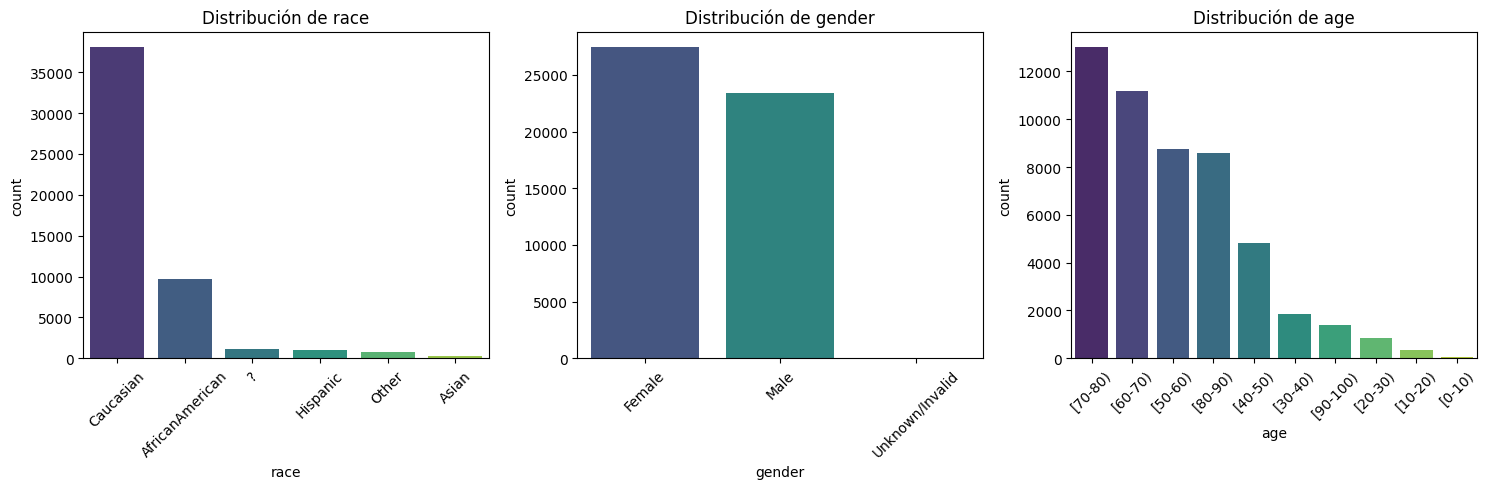

In [12]:
# Esquema del dataset
df.printSchema()

# Análisis de variables categóricas clave
categorical_cols = ['race', 'gender', 'age']

plt.figure(figsize=(15, 5))

for i, col in enumerate(categorical_cols):
    # Agregación en PySpark y paso a Pandas para graficar
    pd_df = df.groupBy(col).count().orderBy("count", ascending=False).toPandas()
    
    plt.subplot(1, 3, i+1)
    sns.barplot(data=pd_df, x=col, y='count', palette='viridis')
    plt.title(f'Distribución de {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

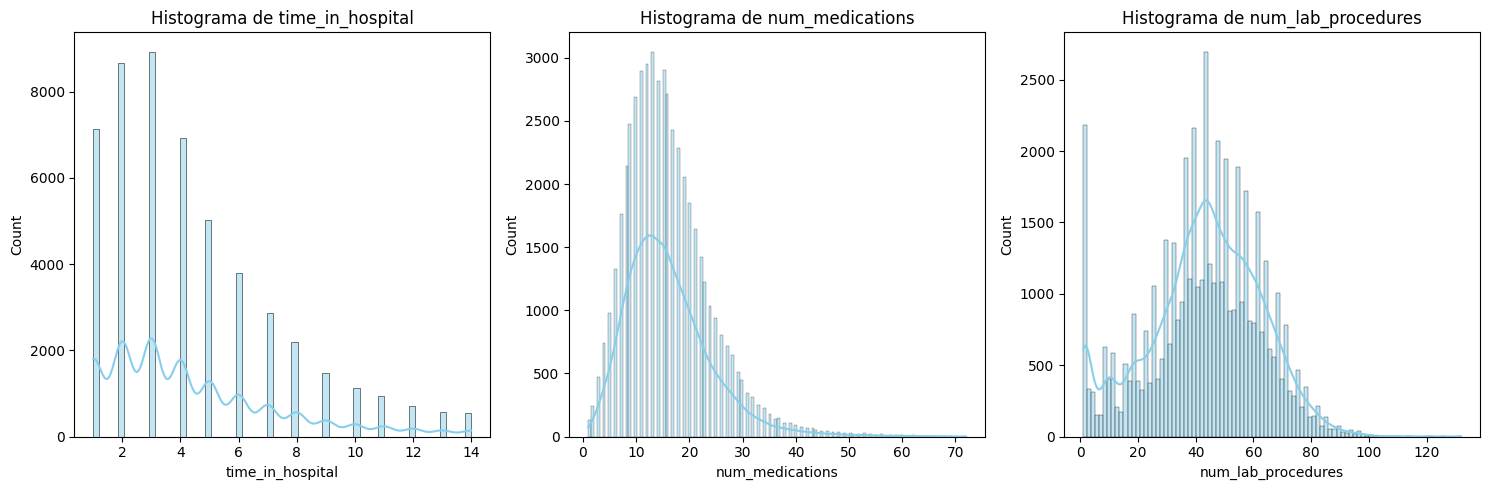

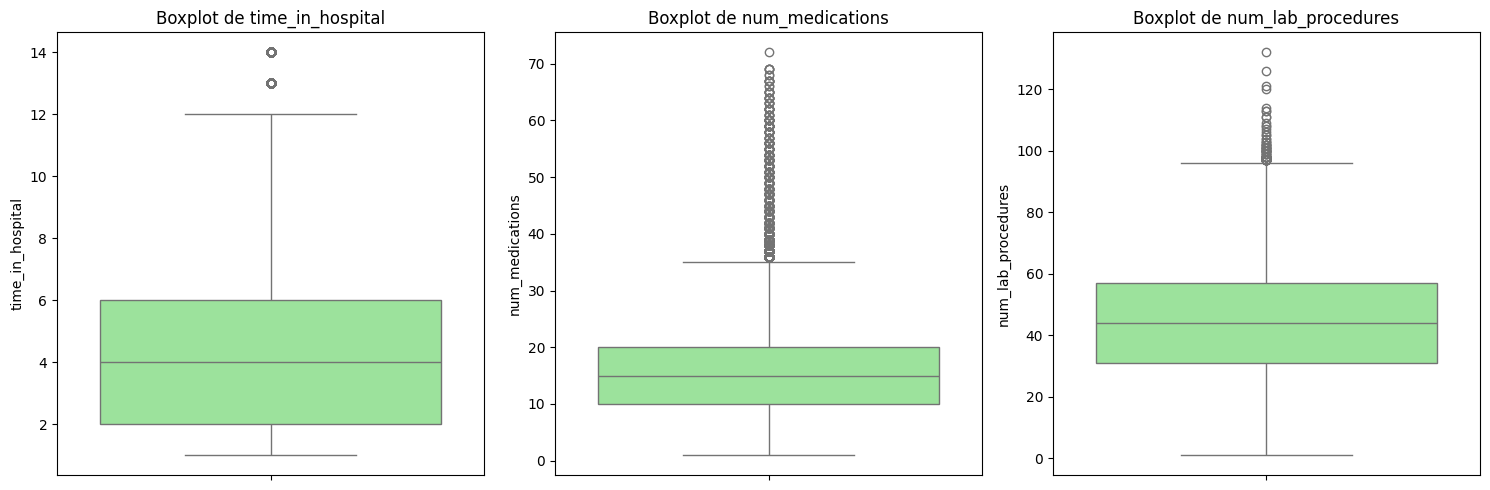

In [13]:
# Análisis de variables numéricas clave
numeric_cols = ['time_in_hospital', 'num_medications', 'num_lab_procedures']

plt.figure(figsize=(15, 5))

for i, col in enumerate(numeric_cols):
    # Seleccionar datos y pasar a Pandas
    pd_series = df.select(col).toPandas()
    
    plt.subplot(1, 3, i+1)
    sns.histplot(pd_series[col], kde=True, color='skyblue')
    plt.title(f'Histograma de {col}')

plt.tight_layout()
plt.show()

# Boxplots para detectar outliers y distribución
plt.figure(figsize=(15, 5))
for i, col in enumerate(numeric_cols):
    pd_series = df.select(col).toPandas()
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=pd_series[col], color='lightgreen')
    plt.title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

1. Limpieza
2. Indexación
3. Codificación
4. Vectorización
5. Escalamiento:
6. PCA (Principal Component Analysis)

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler, PCA
from pyspark.sql.functions import when, col

# Limpieza: '?' y nulos -> 'Unknown' en categóricas
cat_cols = ['race', 'gender', 'age', 'A1Cresult', 'max_glu_serum', 'change', 'insulin']
df_clean = df
for c in cat_cols:
    df_clean = df_clean.withColumn(
        c,
        when((col(c) == '?') | col(c).isNull(), 'Unknown').otherwise(col(c))
    )

# Numéricas clínicas (ampliadas)
num_cols = [
    'time_in_hospital', 'num_medications', 'num_lab_procedures',
    'num_procedures', 'number_diagnoses',
    'number_inpatient', 'number_outpatient', 'number_emergency'
]

# Pipeline: index -> OHE -> assemble -> scale -> PCA
indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in cat_cols]
encoders = [OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe") for c in cat_cols]

assembler = VectorAssembler(
    inputCols=[f"{c}_ohe" for c in cat_cols] + num_cols,
    outputCol="features"
)
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withStd=True, withMean=False)
pca = PCA(k=10, inputCol="scaledFeatures", outputCol="pcaFeatures")

pipeline = Pipeline(stages=indexers + encoders + [assembler, scaler, pca])
model_pipeline = pipeline.fit(df_clean)
dataset_final = model_pipeline.transform(df_clean)

print(f"Features categóricas (OHE): {cat_cols}")
print(f"Features numéricas: {num_cols}")
print(f"Filas listas para clustering: {dataset_final.count()}")
dataset_final.select("features", "scaledFeatures", "pcaFeatures").show(3, truncate=80)


# min max scaler probar para el tipo de escalado, parece que hay muchas columnas que estan 
# aportando ruido por el valor de la solueta, debe ser al menos 0.6

Features categóricas (OHE): ['race', 'gender', 'age', 'A1Cresult', 'max_glu_serum', 'change', 'insulin']
Features numéricas: ['time_in_hospital', 'num_medications', 'num_lab_procedures', 'num_procedures', 'number_diagnoses', 'number_inpatient', 'number_outpatient', 'number_emergency']
Filas listas para clustering: 50883
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                        features|                                                                  scaledFeatures|                                                                     pcaFeatures|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+-------------------------

## Experimento 1: K-Means

Primer experimento usando el algoritmo clásico **K-Means** sobre el vector `pcaFeatures` (10 componentes principales). Se evalúa K = 2..6 con el coeficiente de silueta para justificar la elección del número de clústeres.

Evaluando diferentes valores de K...
K=2 | Silhouette Score = 0.2552
K=3 | Silhouette Score = 0.2658
K=4 | Silhouette Score = 0.2307
K=5 | Silhouette Score = 0.2196
K=6 | Silhouette Score = 0.2590


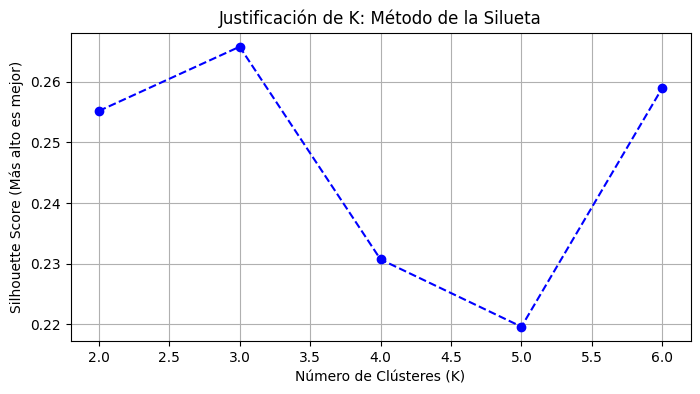

In [15]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt

silhouette_scores = []
# 2, 3, 4, 5 y 6 clústeres
k_values = range(2, 7) 

evaluator = ClusteringEvaluator(predictionCol="prediction", featuresCol="pcaFeatures", metricName="silhouette")

print("Evaluando diferentes valores de K...")
for k in k_values:
    kmeans_temp = KMeans(featuresCol="pcaFeatures", predictionCol="prediction", k=k, seed=42)
    model_temp = kmeans_temp.fit(dataset_final)
    predictions_temp = model_temp.transform(dataset_final)
    
    score = evaluator.evaluate(predictions_temp)
    silhouette_scores.append(score)
    print(f"K={k} | Silhouette Score = {score:.4f}")

# Graficar para justificar visualmente
plt.figure(figsize=(8, 4))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='--', color='b')
plt.title('Justificación de K: Método de la Silueta')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Silhouette Score (Más alto es mejor)')
plt.grid(True)
plt.show()

In [16]:
from pyspark.ml.clustering import KMeans

# Entrenar K-Means definitivo basándose en el mejor valor de la gráfica anterior
mejor_k = 3 # Basado en la evaluación previa
kmeans = KMeans(featuresCol="pcaFeatures", predictionCol="prediction", k=mejor_k, seed=42)
model = kmeans.fit(dataset_final)

# Obtener predicciones
predictions = model.transform(dataset_final)

print(f"Entrenamiento completado. {mejor_k} Clústeres asignados usando PCA.")

Entrenamiento completado. 3 Clústeres asignados usando PCA.


In [17]:
from pyspark.ml.evaluation import ClusteringEvaluator

# Evaluar el modelo final usando el Coeficiente de Silueta sobre pcaFeatures
evaluator = ClusteringEvaluator(predictionCol="prediction", featuresCol="pcaFeatures", metricName="silhouette")

silhouette = evaluator.evaluate(predictions)

print(f"Coeficiente de Silueta Final: {silhouette:.4f}")

Coeficiente de Silueta Final: 0.2658


In [18]:
# Análisis de los perfiles clínicos por clúster
print("Resumen estadístico por Clúster:")
perfiles = predictions.groupBy("prediction") \
    .agg({
        "time_in_hospital": "mean", 
        "num_medications": "mean",
        "num_lab_procedures": "mean"
    }) \
    .orderBy("prediction")

perfiles.show()

# Interpretación textual breve basada en los resultados
print("Interpretación de los Clústeres:")
print("- Clúster 0: Posible perfil de baja intensidad clínica.")
print("- Clúster 1: Pacientes con mayor estancia o medicación.")
print("- Clúster 2: Perfil intermedio o con alta frecuencia de laboratorios.")

Resumen estadístico por Clúster:
+----------+--------------------+-----------------------+---------------------+
|prediction|avg(num_medications)|avg(num_lab_procedures)|avg(time_in_hospital)|
+----------+--------------------+-----------------------+---------------------+
|         0|  14.126233744228406|      40.21663066039734|    4.034100055068412|
|         1|  18.274027977235253|     41.631455773629064|    4.636987394287538|
|         2|  16.311858407079647|      54.09675516224189|   4.7642477876106195|
+----------+--------------------+-----------------------+---------------------+

Interpretación de los Clústeres:
- Clúster 0: Posible perfil de baja intensidad clínica.
- Clúster 1: Pacientes con mayor estancia o medicación.
- Clúster 2: Perfil intermedio o con alta frecuencia de laboratorios.


## Experimento 2: Bisecting K-Means

Segundo experimento con **Bisecting K-Means**, una variante jerárquica divisiva. Parte de un único clúster y lo divide recursivamente mediante K-Means con K=2 hasta alcanzar el número deseado de clústeres. Suele producir agrupaciones más balanceadas y menos sensibles a la inicialización aleatoria que K-Means estándar. Se entrena con el mismo K=3 y las mismas `pcaFeatures` para que la comparación sea justa.

In [19]:
from pyspark.ml.clustering import BisectingKMeans

bkm = BisectingKMeans(featuresCol="pcaFeatures", predictionCol="prediction", k=mejor_k, seed=42)
model_bkm = bkm.fit(dataset_final)
predictions_bkm = model_bkm.transform(dataset_final)

silhouette_bkm = evaluator.evaluate(predictions_bkm)
print(f"Bisecting K-Means | K={mejor_k} | Silhouette = {silhouette_bkm:.4f}")
print("Tamaños de clúster:")
predictions_bkm.groupBy("prediction").count().orderBy("prediction").show()

Bisecting K-Means | K=3 | Silhouette = 0.1931
Tamaños de clúster:
+----------+-----+
|prediction|count|
+----------+-----+
|         0|12384|
|         1|14993|
|         2|23506|
+----------+-----+



## Comparación de Resultados

Se comparan ambos algoritmos con el **coeficiente de silueta** (cohesión vs separación, rango [-1, 1] — más alto es mejor) y el **costo intra-clúster** (suma de distancias cuadradas, más bajo es mejor). Adicionalmente se visualizan los clústeres en 2D proyectando `pcaFeatures` a sus primeras dos componentes.

In [20]:
import pandas as pd

# Costo intra-clúster (Within-Set Sum of Squared Errors)
cost_kmeans = model.summary.trainingCost
cost_bkm = model_bkm.summary.trainingCost

comparison = pd.DataFrame({
    "Métrica": ["Silhouette Score", "Costo intra-clúster (WSSSE)", "K", "Tamaño cluster 0", "Tamaño cluster 1", "Tamaño cluster 2"],
    "K-Means": [
        f"{silhouette:.4f}",
        f"{cost_kmeans:.2f}",
        mejor_k,
        predictions.filter("prediction = 0").count(),
        predictions.filter("prediction = 1").count(),
        predictions.filter("prediction = 2").count(),
    ],
    "Bisecting K-Means": [
        f"{silhouette_bkm:.4f}",
        f"{cost_bkm:.2f}",
        mejor_k,
        predictions_bkm.filter("prediction = 0").count(),
        predictions_bkm.filter("prediction = 1").count(),
        predictions_bkm.filter("prediction = 2").count(),
    ],
})
print("Tabla comparativa de resultados:")
print(comparison.to_string(index=False))

Tabla comparativa de resultados:
                    Métrica   K-Means Bisecting K-Means
           Silhouette Score    0.2658            0.1931
Costo intra-clúster (WSSSE) 737964.77         757371.10
                          K         3                 3
           Tamaño cluster 0     23607             12384
           Tamaño cluster 1     18801             14993
           Tamaño cluster 2      8475             23506


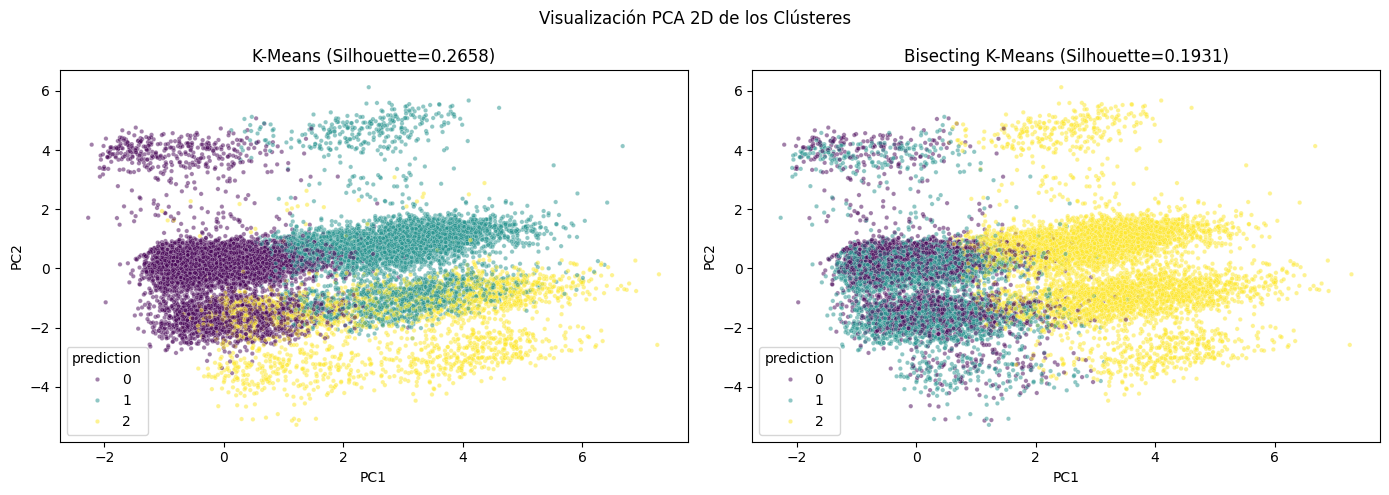

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType

# Extraer las primeras 2 componentes PCA para visualización 2D
first  = udf(lambda v: float(v[0]), DoubleType())
second = udf(lambda v: float(v[1]), DoubleType())

def to_pandas_2d(preds):
    return preds.select(
        first("pcaFeatures").alias("PC1"),
        second("pcaFeatures").alias("PC2"),
        "prediction"
    ).sample(fraction=0.3, seed=42).toPandas()  # muestra para que el plot no sature

pdf_km  = to_pandas_2d(predictions)
pdf_bkm = to_pandas_2d(predictions_bkm)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=pdf_km,  x="PC1", y="PC2", hue="prediction", palette="viridis",
                s=10, alpha=0.5, ax=axes[0], legend="full")
axes[0].set_title(f"K-Means (Silhouette={silhouette:.4f})")
sns.scatterplot(data=pdf_bkm, x="PC1", y="PC2", hue="prediction", palette="viridis",
                s=10, alpha=0.5, ax=axes[1], legend="full")
axes[1].set_title(f"Bisecting K-Means (Silhouette={silhouette_bkm:.4f})")
plt.suptitle("Visualización PCA 2D de los Clústeres")
plt.tight_layout()
plt.show()

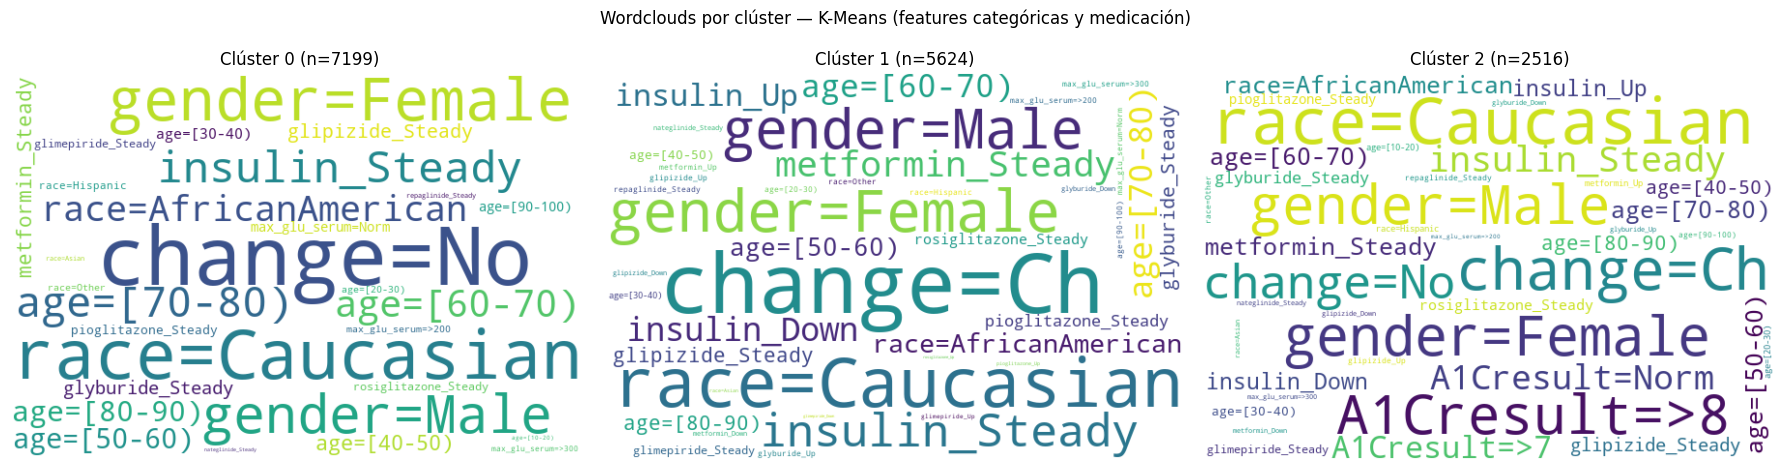

In [22]:
from wordcloud import WordCloud
from collections import Counter
from pyspark.sql.functions import lit

# Construir vocabulario por clúster (modelo K-Means)
# Tokens = race, age, gender, A1Cresult, max_glu_serum, change + medicamentos activos
med_cols = ['metformin', 'insulin', 'glipizide', 'glyburide', 'pioglitazone',
            'rosiglitazone', 'glimepiride', 'repaglinide', 'nateglinide']

token_cols = ['race', 'gender', 'age', 'A1Cresult', 'max_glu_serum', 'change'] + med_cols
sample = predictions.select(['prediction'] + token_cols).sample(fraction=0.3, seed=42).toPandas()

fig, axes = plt.subplots(1, mejor_k, figsize=(6 * mejor_k, 5))
if mejor_k == 1:
    axes = [axes]

for cid in range(mejor_k):
    sub = sample[sample['prediction'] == cid]
    counter = Counter()
    for _, row in sub.iterrows():
        for c in ['race', 'gender', 'age', 'A1Cresult', 'max_glu_serum', 'change']:
            v = str(row[c])
            if v and v != 'Unknown' and v != 'None':
                counter[f"{c}={v}"] += 1
        for m in med_cols:
            v = str(row[m])
            if v not in ('No', 'None', 'nan'):
                counter[f"{m}_{v}"] += 1

    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap='viridis', max_words=40).generate_from_frequencies(counter)
    axes[cid].imshow(wc, interpolation='bilinear')
    axes[cid].axis('off')
    axes[cid].set_title(f"Clúster {cid} (n={len(sub)})")

plt.suptitle("Wordclouds por clúster — K-Means (features categóricas y medicación)")
plt.tight_layout()
plt.show()

## Nombres y Discusión de Clusters

Para asignar un nombre clínico a cada clúster se examinan los valores promedio de las variables numéricas (estancia, medicaciones, procedimientos, diagnósticos, visitas previas) y la distribución de readmisión por grupo. Las etiquetas propuestas combinan **intensidad clínica** (cuántos recursos consume el paciente) y **patrón de recurrencia** (re-hospitalizaciones).

In [23]:
from pyspark.sql.functions import avg, count, sum as _sum, when as _when

# Perfil clínico detallado por clúster (modelo K-Means)
profile = predictions.groupBy("prediction").agg(
    count("*").alias("n"),
    avg("time_in_hospital").alias("avg_estancia_dias"),
    avg("num_medications").alias("avg_medicamentos"),
    avg("num_lab_procedures").alias("avg_lab_procs"),
    avg("num_procedures").alias("avg_procedimientos"),
    avg("number_diagnoses").alias("avg_diagnosticos"),
    avg("number_inpatient").alias("avg_hospitalizaciones_previas"),
    avg("number_emergency").alias("avg_emergencias_previas"),
    _sum(_when(col("readmitted") == "<30", 1).otherwise(0)).alias("readm_menos30d"),
).orderBy("prediction")

profile_pd = profile.toPandas()
profile_pd["tasa_readm_<30d_%"] = (profile_pd["readm_menos30d"] / profile_pd["n"] * 100).round(2)
profile_pd = profile_pd.drop(columns=["readm_menos30d"]).round(2)
print("Perfil clínico por clúster (K-Means):")
print(profile_pd.to_string(index=False))

# Asignar nombres por ranking relativo entre clusters
def asignar_nombres(df):
    # Cluster con mayor recurrencia (hospitalizaciones + emergencias previas)
    df = df.copy()
    df['score_recurrencia']  = df['avg_hospitalizaciones_previas'] + df['avg_emergencias_previas']
    df['score_intensidad']   = df['avg_estancia_dias'] + df['avg_medicamentos'] / 5 + df['avg_lab_procs'] / 10
    df['rank_recurrencia']   = df['score_recurrencia'].rank(ascending=False).astype(int)
    df['rank_intensidad']    = df['score_intensidad'].rank(ascending=False).astype(int)

    nombres = {}
    # 1. El de mayor recurrencia + alta readmisión = recurrentes
    idx_rec = df['score_recurrencia'].idxmax()
    nombres[int(df.loc[idx_rec,'prediction'])] = "Pacientes recurrentes / alta carga farmacológica"
    # 2. De los restantes, el de mayor intensidad clínica = casos complejos
    restantes = df.drop(idx_rec)
    idx_int = restantes['score_intensidad'].idxmax()
    nombres[int(restantes.loc[idx_int,'prediction'])] = "Pacientes en evaluación intensiva / casos complejos"
    # 3. El último = perfil rutinario
    for cid in df['prediction'].astype(int):
        nombres.setdefault(cid, "Pacientes ambulatorios / control rutinario")
    return nombres

nombres = asignar_nombres(profile_pd)
print("\nNombres asignados a cada clúster:")
for cid in sorted(nombres):
    print(f"  - Clúster {cid}: {nombres[cid]}")

Perfil clínico por clúster (K-Means):
 prediction     n  avg_estancia_dias  avg_medicamentos  avg_lab_procs  avg_procedimientos  avg_diagnosticos  avg_hospitalizaciones_previas  avg_emergencias_previas  tasa_readm_<30d_%
          0 23607               4.03             14.13          40.22                1.36              7.36                           0.63                     0.17              10.85
          1 18801               4.64             18.27          41.63                1.35              7.54                           0.72                     0.24              12.31
          2  8475               4.76             16.31          54.10                1.28              7.37                           0.45                     0.18               9.83

Nombres asignados a cada clúster:
  - Clúster 0: Pacientes ambulatorios / control rutinario
  - Clúster 1: Pacientes recurrentes / alta carga farmacológica
  - Clúster 2: Pacientes en evaluación intensiva / casos complejos
